In [1]:
import torch
import numpy as np
import random
from models import *
import matplotlib.pyplot as plt
from diffusers import LMSDiscreteScheduler, DDIMScheduler, AutoencoderKL
from utils import *
import timeit
import h5py

from interpolation_baselines.C_space import *
from evaluation import *
from ddim import *
from Cebra import cebra_model

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the autoencoder model which will be used to decode the latents into image space. 
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")
# To the GPU we go!
vae = vae.to(device)


# The noise scheduler
noise_scheduler = LMSDiscreteScheduler(
    beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000
)

In [2]:
# Load Data
M = 20

labels_raw = np.load('data/raw_labels_{}.npy'.format(M))
Z_data = np.load('data/ddim_latents_{}.npy'.format(M))
ca_labels = np.load('data/norm_labels_{}.npy'.format(M))

labels = ca_labels[:,1]
num_frames = len(labels)

In [3]:
num_frames

4800

In [4]:
number_list = list(range(4800))
train_block_size = 41
test_block_size = 7
num_blocks = 100
train_blocks = [number_list[i * (train_block_size+test_block_size)  : (i + 1) * train_block_size + test_block_size*i] 
                for i in range(num_blocks)]
test_blocks = [number_list[(i + 1) * train_block_size + test_block_size*i : (i+1)*(train_block_size + test_block_size)]
               for i in range(num_blocks)]  
idx_train = []
idx_test = []
for j in range(num_blocks):
    idx_train = idx_train + train_blocks[j]
    idx_test = idx_test + test_blocks[j]

print("Train:", len(idx_train), "Test:", len(idx_test))

cebra_model.fit(Z_data[idx_train],ca_labels[idx_train])
C_train = cebra_model.transform(Z_data[idx_train])
C_test = cebra_model.transform(Z_data[idx_test])

Train: 4100 Test: 700


pos:  4.1776 neg: -6.7519 total: -2.5743


In [5]:
import numpy as np

Z = cebra_model.transform(Z_data)

def quad_derivs_at_end(Zw, tw, lam=0.0):
    """
    Zw: (W,D) last W latent vectors, tw: (W,) times (uniform or not)
    Returns (zT, dzT, ddzT) evaluated at t=tw[-1].
    """
    Zw = np.asarray(Zw); tw = np.asarray(tw, float)
    W, D = Zw.shape
    A = np.column_stack([tw**2, tw, np.ones_like(tw)])            # (W,3)
    if lam > 0:
        AtA = A.T @ A + lam*np.eye(3)
        coeffs = np.linalg.solve(AtA, A.T @ Zw)                   # (3,D)
    else:
        coeffs = np.linalg.lstsq(A, Zw, rcond=None)[0]
    a, b, c = coeffs                                              # each (D,)
    tT = tw[-1]
    zT   = (a*(tT**2) + b*tT + c)
    dzT  = (2*a*tT + b)
    ddzT = (2*a)
    return zT, dzT, ddzT

def tex2_extrapolate(
    Z, t, horizon=1, W=3, substeps=1, lam=1e-5
):
    """
    Z: (T,D), t: (T,) timestamps (can be non-uniform).
    Returns preds: (horizon, D)
    """
    Z = np.asarray(Z); t = np.asarray(t, float)
    T, D = Z.shape
    W = min(W, T)

    # Use median dt as the nominal step (works for mildly irregular sampling)
    dt_nom = np.median(np.diff(t[-W:]))

    # Working buffers (start with last W truths)
    Zbuf = Z[-W:].copy()
    tbuf = t[-W:].copy()
    preds = []

    for _ in range(horizon):
        # do optional sub-steps to reduce truncation error
        dts = dt_nom / substeps
        for __ in range(substeps):
            zT, dzT, ddzT = quad_derivs_at_end(Zbuf, tbuf, lam=lam)
            # second-order Taylor step
            z_next = zT + dzT*dts + 0.5*ddzT*(dts**2)
            t_next = tbuf[-1] + dts
            # slide window
            if W > 1:
                Zbuf = np.vstack([Zbuf[1:], z_next])
                tbuf = np.hstack([tbuf[1:], t_next])
            else:  # degenerate W=1
                Zbuf[-1] = z_next; tbuf[-1] = t_next
        preds.append(Zbuf[-1].copy())

    return np.stack(preds, axis=0)
H = 7
pred = []
tex2_test_pred = []
tex2_rmse_blocks = []
for b in range(num_blocks):
    t_tr = np.array(train_blocks[b], dtype=int)
    t_te = np.array(test_blocks[b], dtype=int)  # horizon truth indices

    tt = labels[t_tr]
    tt_te = labels[t_te]

    x = Z[t_tr]

    for k in range(H):
        # predict next step (store it)
        tex2_extrap = tex2_extrapolate(x, tt)
        x = np.concatenate([x[1:], tex2_extrap], axis=0)

        # shift labels window and append the next test label
        tt = np.concatenate([tt[1:], tt_te[k:k+1]], axis=0)

        # store prediction WITHOUT the time axis (store a single frame)
        pred.append(tex2_extrap[0])
    pred_arr = np.stack(pred, axis=0)          # shape: (H, ...)
    tex2_test_pred = pred_arr
    truth = Z[t_te]                             # expected shape: (H, ...)
    # RMSE per-step over all non-time dims
    rmse_b = np.sqrt(np.mean((truth - pred_arr[H*b:H*(b+1)]) ** 2, axis=1))
    tex2_rmse_blocks.append(rmse_b)

In [6]:
# Spline Extrapolation
import numpy as np
from scipy.interpolate import splprep, splev

H = 7  # forecast horizon (H points)

spline_rmse_blocks = []
spline_test_pred = []
for b in range(num_blocks):
#for b in range(10, 11):
    # ---- 1) Parameterize by (normalized) time, not chord-length ----
    idx_tr = np.array(train_blocks[b], dtype=int)
    idx_te = np.array(test_blocks[b],  dtype=int)
    Z_tr   = Z[idx_tr]                         # (W,D)
    t_tr   = labels[idx_tr].astype(float)
    t_te   = labels[idx_te].astype(float)

    # Normalize times for conditioning (optional but helpful)
    t0, t1 = t_tr[0], t_tr[-1]
    u_tr = (t_tr - t0) / (t1 - t0 + 1e-12)     # u_tr in [0,1]
    du   = np.median(np.diff(u_tr))            # typical step in u

    # ---- 2) Fit parametric spline with smoothing ----
    # k=3 (cubic). If window is small (W<5), use k=2 for stability.
    k = 3 if len(u_tr) >= 5 else 2
    # Set a small smoothing s>0 to reduce wobble; tune s to your noise level
    # (scale by W to keep behavior consistent across block sizes).
    s = 1e1 * len(u_tr)

    # splprep expects data shape (D, W) -> transpose Z_tr
    tck, u_out = splprep(Z_tr.T, u=u_tr, k=3, s=s)

    # ---- 3) Extrapolate beyond the last knot ----
    u_last = u_tr[-1]
    u_extrap = u_last + du * np.arange(1, H+1)     # strictly > u_last

    # splev(..., ext=2) tells SciPy to extrapolate outside the data domain
    spline_extrap = np.array(splev(u_extrap, tck, ext=0)).T   # (H,D)
    #print(spline_extrap)

    # ---- 4) Compute RMSE per-step (shape (H,)) ----
    truth = Z[idx_te]
    pred  = spline_extrap
    spline_test_pred.append(spline_extrap)
    rmse_b = np.sqrt(np.mean((truth - pred)**2, axis=1))
    spline_rmse_blocks.append(rmse_b)

In [7]:
# LSTM-model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset

# Convert inputs to tensors
latent_codes = torch.tensor(Z[idx_train], dtype=torch.float32)  # (3000, 8)
time_labels = torch.tensor(labels[idx_train], dtype=torch.float32)  # (3000)

def prepare_sequences(latent_tensor, time_tensor, input_len=20, output_len=1):
    X, Y, T = [], [], []
    total_steps = latent_tensor.shape[0]
    for i in range(total_steps - input_len - output_len + 1):
        X.append(latent_tensor[i:i+input_len])
        Y.append(latent_tensor[i+input_len:i+input_len+output_len])
        T.append(time_tensor[i:i+input_len])
    return torch.stack(X), torch.stack(Y), torch.stack(T)

input_seqs, target_seqs, time_seqs = prepare_sequences(latent_codes, time_labels, input_len=20, output_len=1)

# LSTM model 
class TimeConditionedLatentLSTM(nn.Module):
    def __init__(self, latent_dim=3, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=latent_dim + 1, hidden_size=hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, latent_codes, time_labels):
        x = torch.cat((latent_codes, time_labels), dim=-1)  # (batch, seq_len, 4)
        lstm_out, _ = self.lstm(x)
        final_out = lstm_out[:, -1:, :]  # (batch, 1, hidden_dim)
        #final_out = final_out.repeat(1, 12, 1)
        pred = self.fc(final_out)       # (batch, 12, latent_dim)
        return pred


dataset = TensorDataset(input_seqs, target_seqs, time_seqs)
train_size = int(0.8 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

model = TimeConditionedLatentLSTM(latent_dim=3, hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# # Number of epochs
num_epochs = 500

 # Lists to store losses for visualization or analysis later
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for latent_codes, future_latents, time_labels in train_loader:
        optimizer.zero_grad()
        
        # Ensure time_labels has the shape (batch_size, seq_len, 1)
        time_labels = time_labels.unsqueeze(-1)
        
        # Forward pass
        output = model(latent_codes, time_labels)
        
        # Compute training loss
        train_loss = criterion(output, future_latents)
        train_loss.backward()
        optimizer.step()

        total_train_loss += train_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation
    model.eval()
    total_test_loss = 0

    with torch.no_grad():
        for latent_codes, future_latents, time_labels in test_loader:
            time_labels = time_labels.unsqueeze(-1)
            output = model(latent_codes, time_labels)
            test_loss = criterion(output, future_latents)
            total_test_loss += test_loss.item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {avg_train_loss:.4f}  Test Loss: {avg_test_loss:.4f}")

Epoch [10/500]  Train Loss: 594.8342  Test Loss: 536.8515
Epoch [20/500]  Train Loss: 156.9344  Test Loss: 150.9093
Epoch [30/500]  Train Loss: 65.3902  Test Loss: 63.9879
Epoch [40/500]  Train Loss: 29.0143  Test Loss: 28.1651
Epoch [50/500]  Train Loss: 13.6661  Test Loss: 13.4074
Epoch [60/500]  Train Loss: 8.1440  Test Loss: 7.4819
Epoch [70/500]  Train Loss: 4.8093  Test Loss: 4.5436
Epoch [80/500]  Train Loss: 3.3153  Test Loss: 3.3603
Epoch [90/500]  Train Loss: 2.7592  Test Loss: 2.3830
Epoch [100/500]  Train Loss: 2.1678  Test Loss: 1.8546
Epoch [110/500]  Train Loss: 1.8957  Test Loss: 1.7519
Epoch [120/500]  Train Loss: 1.5681  Test Loss: 1.2812
Epoch [130/500]  Train Loss: 1.5676  Test Loss: 1.5157
Epoch [140/500]  Train Loss: 1.3074  Test Loss: 1.3161
Epoch [150/500]  Train Loss: 1.2069  Test Loss: 1.0596
Epoch [160/500]  Train Loss: 1.1632  Test Loss: 1.0069
Epoch [170/500]  Train Loss: 1.1090  Test Loss: 1.0640
Epoch [180/500]  Train Loss: 1.0792  Test Loss: 1.0304
Epoch

In [8]:
# LSTM predictions
latent_codes = torch.tensor(Z, dtype=torch.float32)  # (3000, embedding-dim)
time_labels = torch.tensor(labels, dtype=torch.float32)  # (3000)


pred_output = []
lstm_rmse_blocks = []
H = test_block_size
L = 20  # window length your model expects

model.eval()
with torch.no_grad():
    for b in range(num_blocks):
        t_tr = np.array(train_blocks[b], dtype=int)
        t_te = np.array(test_blocks[b],  dtype=int)[:H]   # horizon truth
        
        # take last L points from training block as input window
        idx_win = t_tr[-L:]
        x = latent_codes[idx_win].unsqueeze(0)                       # (1, L, D)
        tt = time_labels[idx_win].unsqueeze(0).unsqueeze(-1)         # (1, L, 1)
        tt_te = time_labels[t_te].unsqueeze(0).unsqueeze(-1)         # (1, H, 1)
        
        # estimate dt from last two time points (assumes regular-ish sampling)
        #dt = (tt[:, -1:, :] - tt[:, -2:-1, :]).clone()               # (1,1,1)
        preds = []
        for k in range(H):
            y1 = model(x, tt)          # MUST be (1, D) one-step prediction
            #if y1.ndim == 3:           # safety: if (1,1,D)
            #    y1 = y1[:, -1, :]
            #print(y1.shape)
            preds.append(y1[0,0,:])  # (D,)

            # advance time by dt
            #next_t = tt[:, -1:, :] + dt  # (1,1,1)
            next_t = tt_te[0,k].unsqueeze(0).unsqueeze(-1)
            # shift window left and append predicted latent at end
            x  = torch.cat([x[:, 1:, :],  y1], dim=1)   # (1, L, D)
            tt = torch.cat([tt[:, 1:, :], next_t], dim=1)            # (1, L, 1)

        pred_seq = torch.stack(preds, dim=0)                         # (H, D)
        pred_output.append(pred_seq)

        truth = latent_codes[t_te]                                   # (H, D)
        rmse = torch.sqrt(torch.mean((truth - pred_seq)**2, dim=1))  # (H,)
        lstm_rmse_blocks.append(rmse.cpu().numpy())

prediction_output = torch.stack(pred_output, dim=0)  # (B, H, D)
lstm_pred = prediction_output.cpu().numpy()
print("lstm_pred shape:", lstm_pred.shape)

lstm_pred shape: (100, 7, 3)


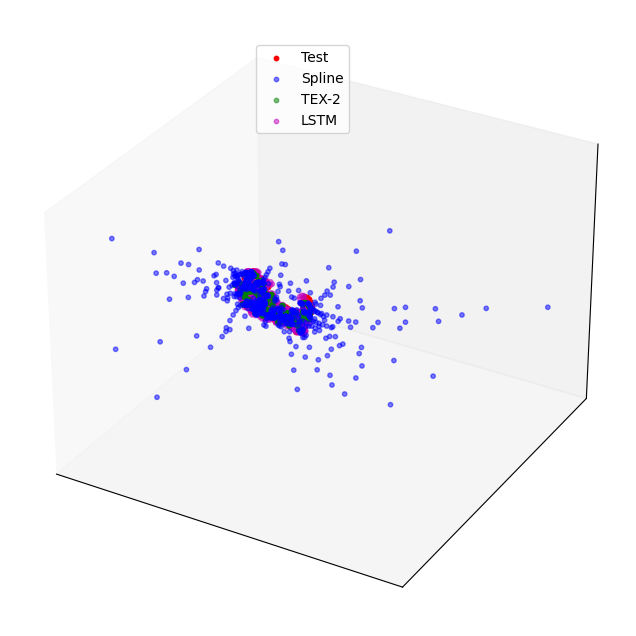

In [9]:
c_tex2 = np.array(tex2_test_pred).reshape(-1,3)
c_spline = np.array(spline_test_pred).reshape(-1,3)
c_lstm = lstm_pred.reshape(-1,3)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

sc = ax.scatter(C_test[:,0], C_test[:,1], C_test[:,2],
                s=10, c='r', alpha=1, label='Test')
ax.scatter(c_spline[:,0],c_spline[:,1],c_spline[:,2], s=10, c='b', alpha=0.5, label='Spline')
ax.scatter(c_tex2[:,0],c_tex2[:,1],c_tex2[:,2], s=10, c='g', alpha=0.5, label='TEX-2')
ax.scatter(c_lstm[:,0],c_lstm[:,1],c_lstm[:,2], s=10, c='m', alpha=0.5, label='LSTM')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.legend(loc=(0.4,0.8))

In [10]:
# kNN Decoding
import cebra
kNN_decoder = cebra.KNNDecoder(n_neighbors=15, metric="euclidean")
kNN_decoder.fit(C_train, Z_data[idx_train])

z_knn = kNN_decoder.predict(C_test)
z_tex2 = kNN_decoder.predict(c_tex2)
z_spline = kNN_decoder.predict(c_spline)
z_lstm = kNN_decoder.predict(c_lstm)


In [11]:
niters = 50000
save_models_folder = 'output/saved_models'

Filename_LDM = save_models_folder + '/CcLDM_checkpoint_intrain/CcLDM_checkpoint_niters_{}.pth'.format(niters)
print("Loading pre-trained continuous conditional latent diffusion model >>>")
checkpoint = torch.load(Filename_LDM, map_location=device, weights_only=True)
netLDM = cont_cond_unet_diffusion_model().to(device)
netLDM = nn.DataParallel(netLDM)

# Adjust checkpoint keys if necessary
checkpoint_state_dict = checkpoint['netLDM_state_dict']
adjusted_state_dict = {}

for key, value in checkpoint_state_dict.items():
    # Replace naming inconsistencies
    new_key = key.replace("query", "to_q").replace("key", "to_k").replace("value", "to_v").replace("proj_attn", "to_out.0")
    adjusted_state_dict[new_key] = value

# Load the adjusted state dict
netLDM.load_state_dict(adjusted_state_dict, strict=True)

Loading pre-trained continuous conditional latent diffusion model >>>


<All keys matched successfully>

In [12]:
X_data = np.load('data/X_data_{}.npy'.format(M))[idx_test]
#print(X_data.shape)
i = list(range(0,len(idx_test),14))
real_images = torch.tensor(X_data[i]).type(torch.float) 

inf_steps = 1000
test_labels = torch.tensor(ca_labels[idx_test]).type(torch.float).unsqueeze(-1).to(device)

  0%|          | 0/999 [00:00<?, ?it/s]

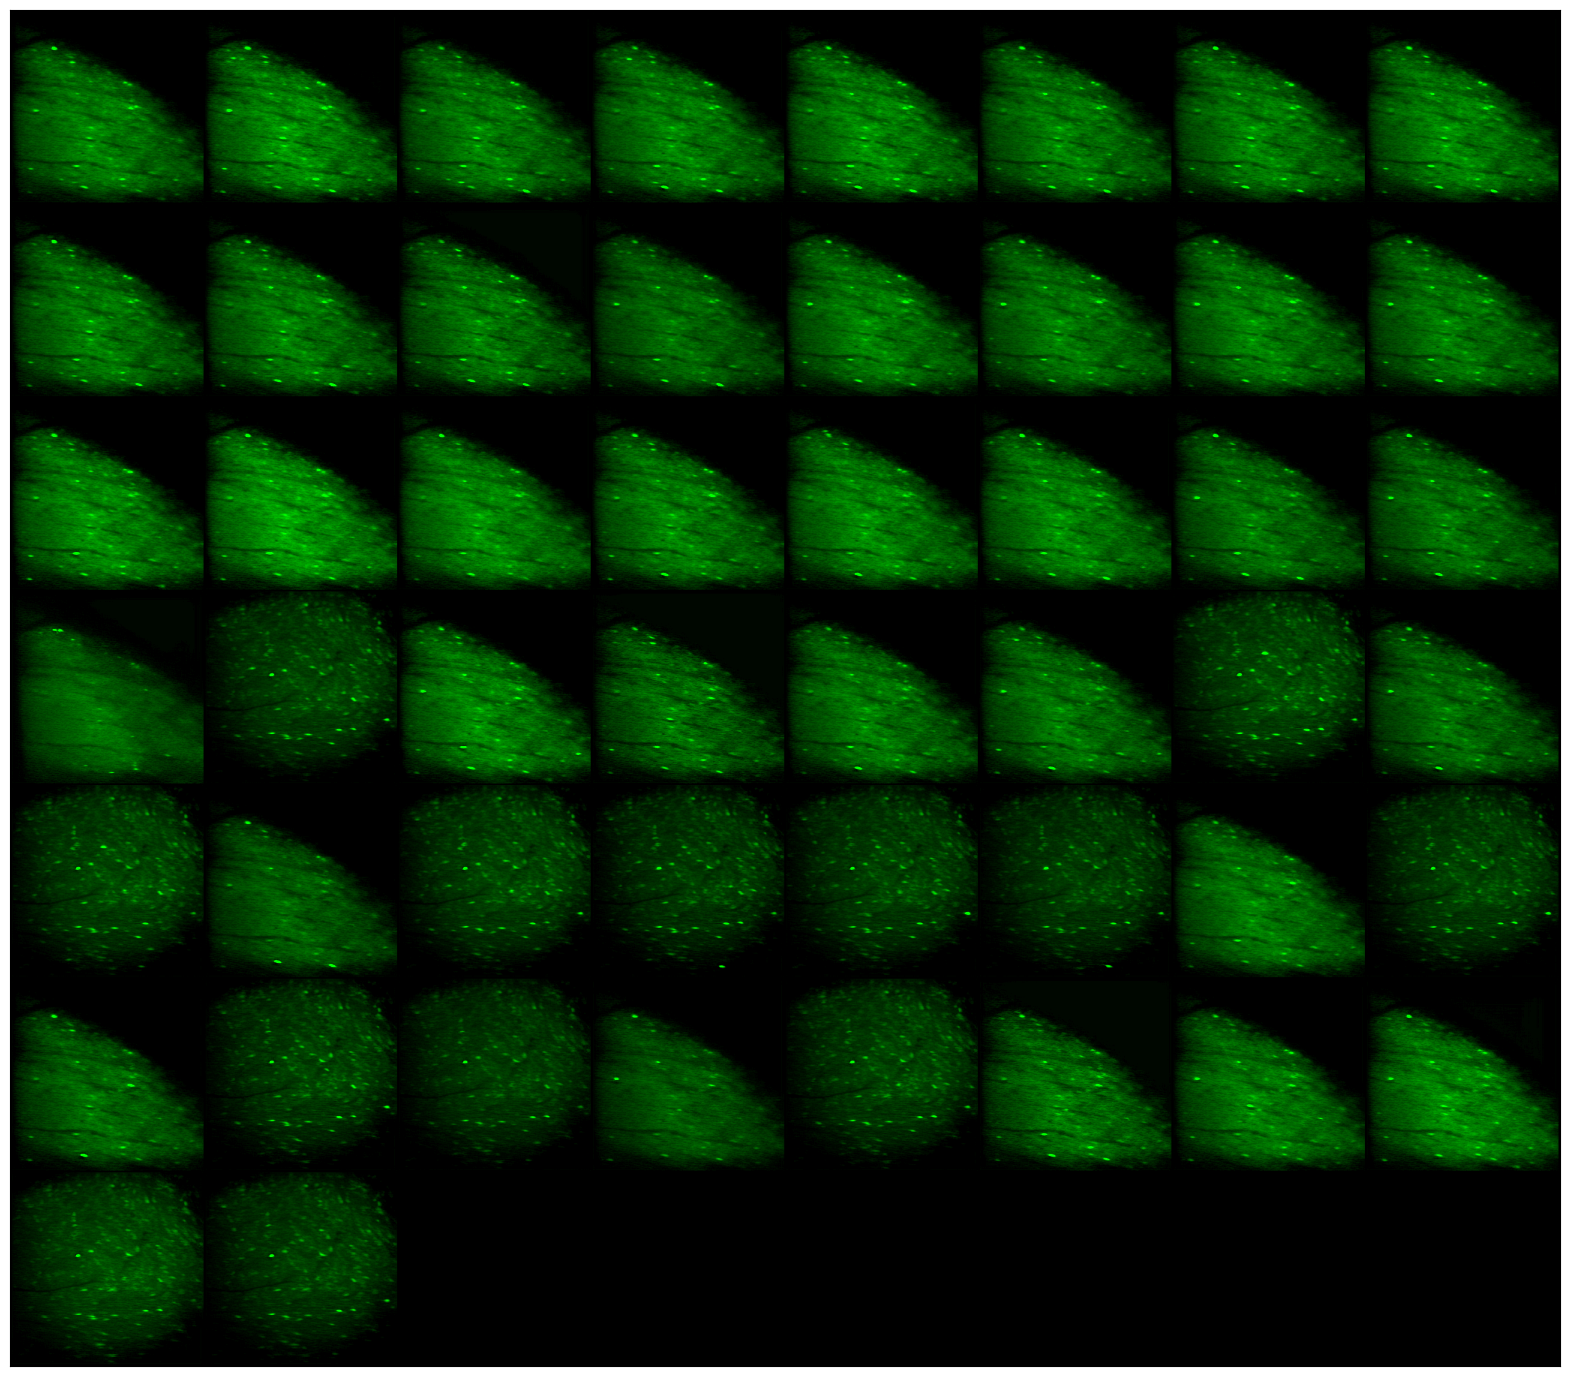

In [13]:
lstm = torch.tensor(z_lstm.reshape(len(idx_test),4,32,32)).type(torch.float).to(device)

lstm_ddim_latents = sample(start_latents=lstm[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
lstm_sample = (1 / 0.18215) * lstm_ddim_latents[-1]
with torch.no_grad():
    x_lstm = vae.decode(lstm_sample).sample 
show_images(x_lstm)    

  0%|          | 0/999 [00:00<?, ?it/s]

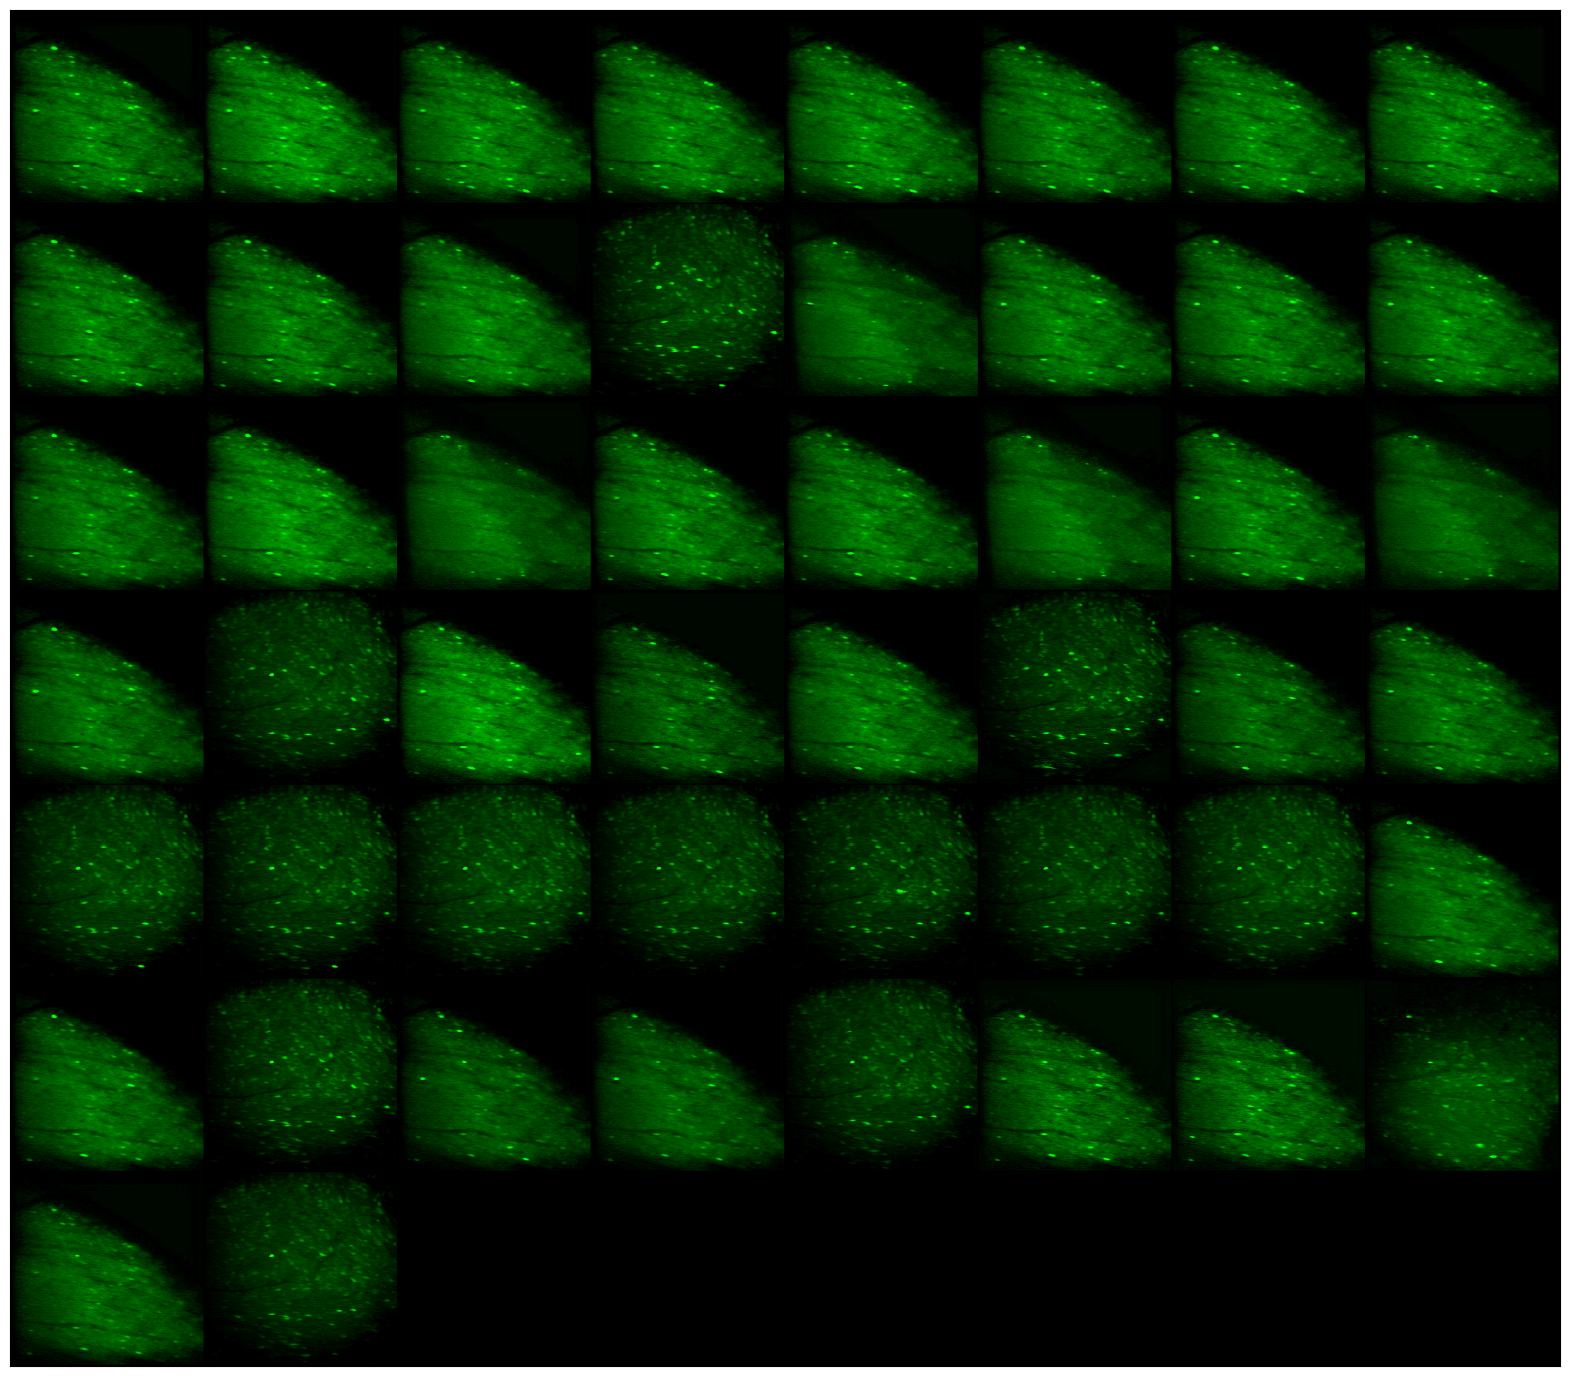

In [14]:
tex2 = torch.tensor(z_tex2.reshape(len(idx_test),4,32,32)).type(torch.float).to(device)

tex2_ddim_latents = sample(start_latents=tex2[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
tex2_sample = (1 / 0.18215) * tex2_ddim_latents[-1]
with torch.no_grad():
    x_tex2 = vae.decode(tex2_sample).sample 
show_images(x_tex2)

  0%|          | 0/999 [00:00<?, ?it/s]

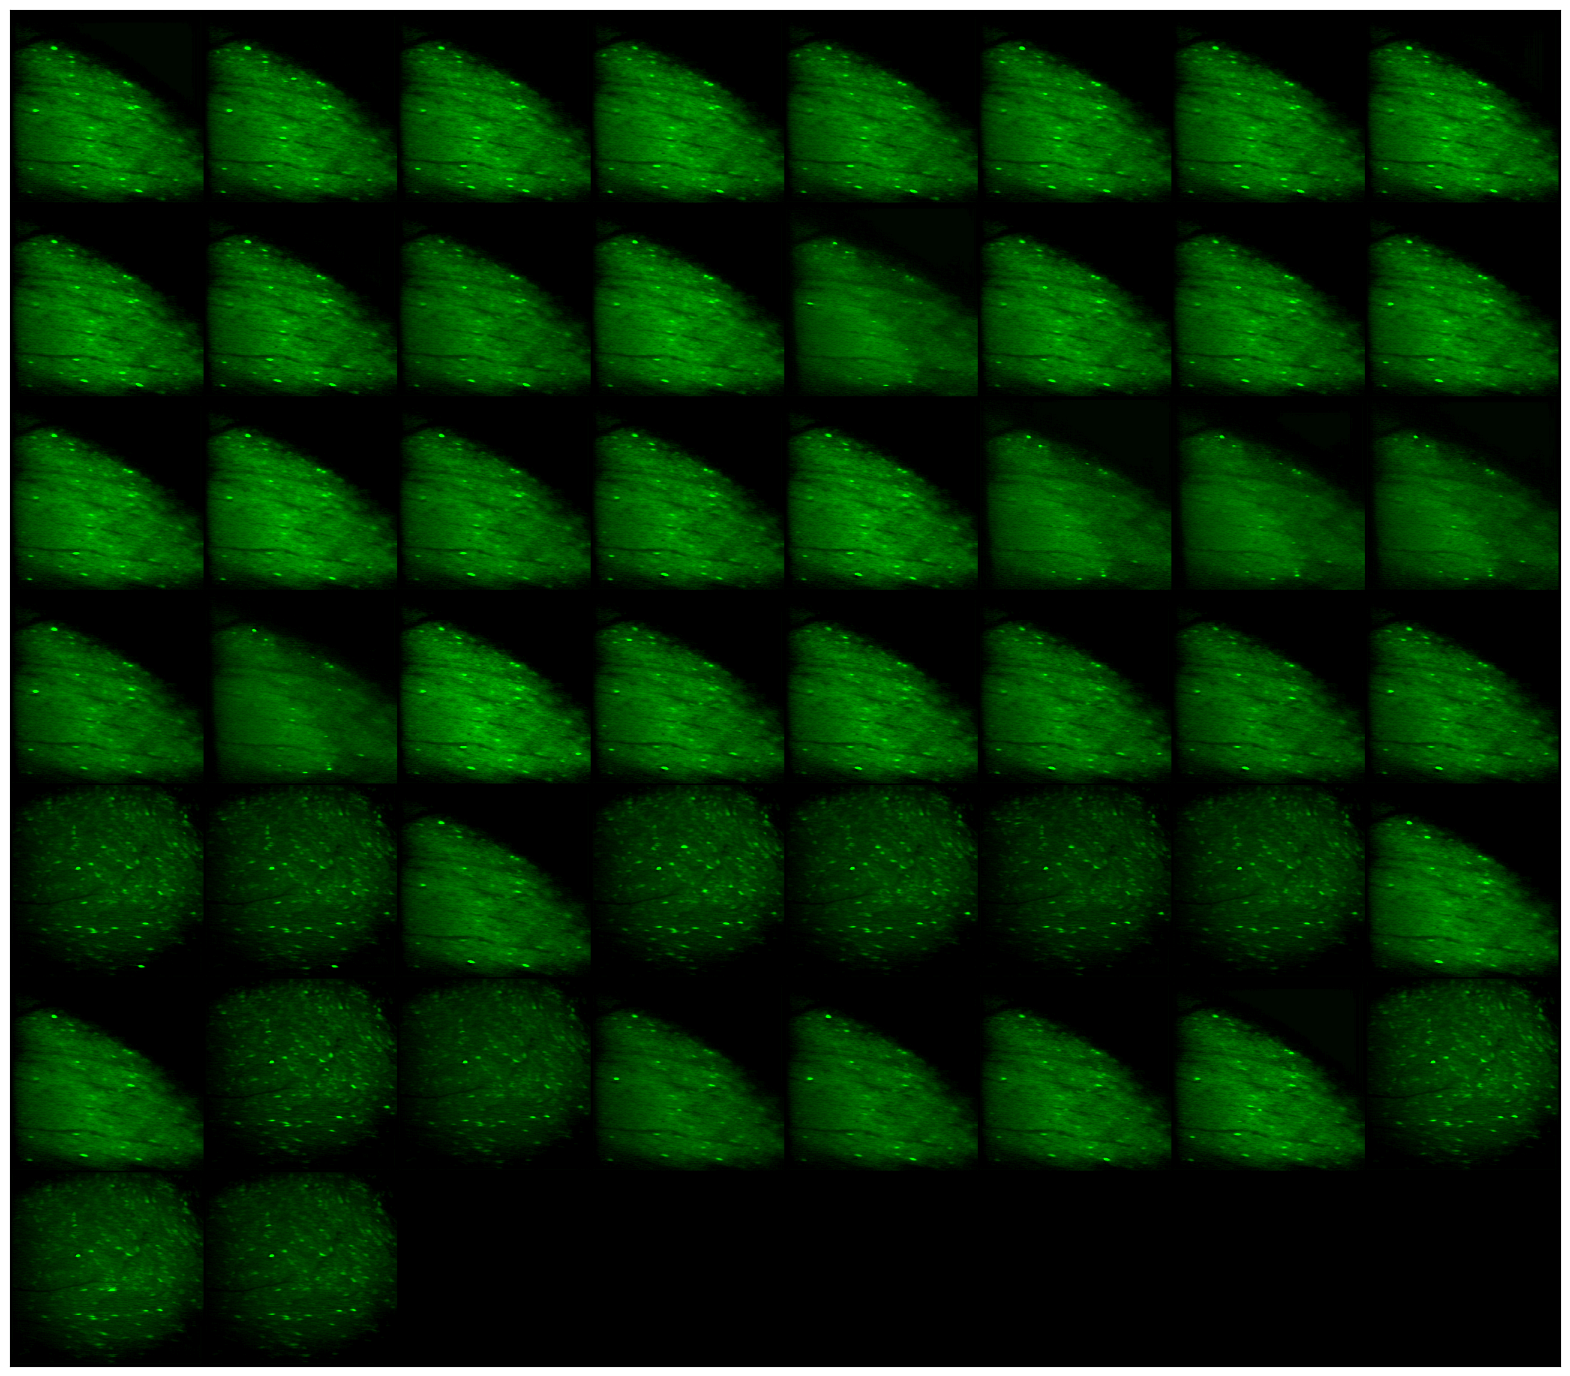

In [15]:
spline = torch.tensor(z_spline.reshape(len(idx_test),4,32,32)).type(torch.float).to(device)

spline_ddim_latents = sample(start_latents=spline[i], num_inference_steps=inf_steps, 
                           labels=test_labels[i], noise_scheduler=noise_scheduler, netLDM=netLDM, 
                           start_step=0, device=device)
spline_sample = (1 / 0.18215) * spline_ddim_latents[-1]
with torch.no_grad():
    x_spline = vae.decode(spline_sample).sample 
show_images(x_spline)    

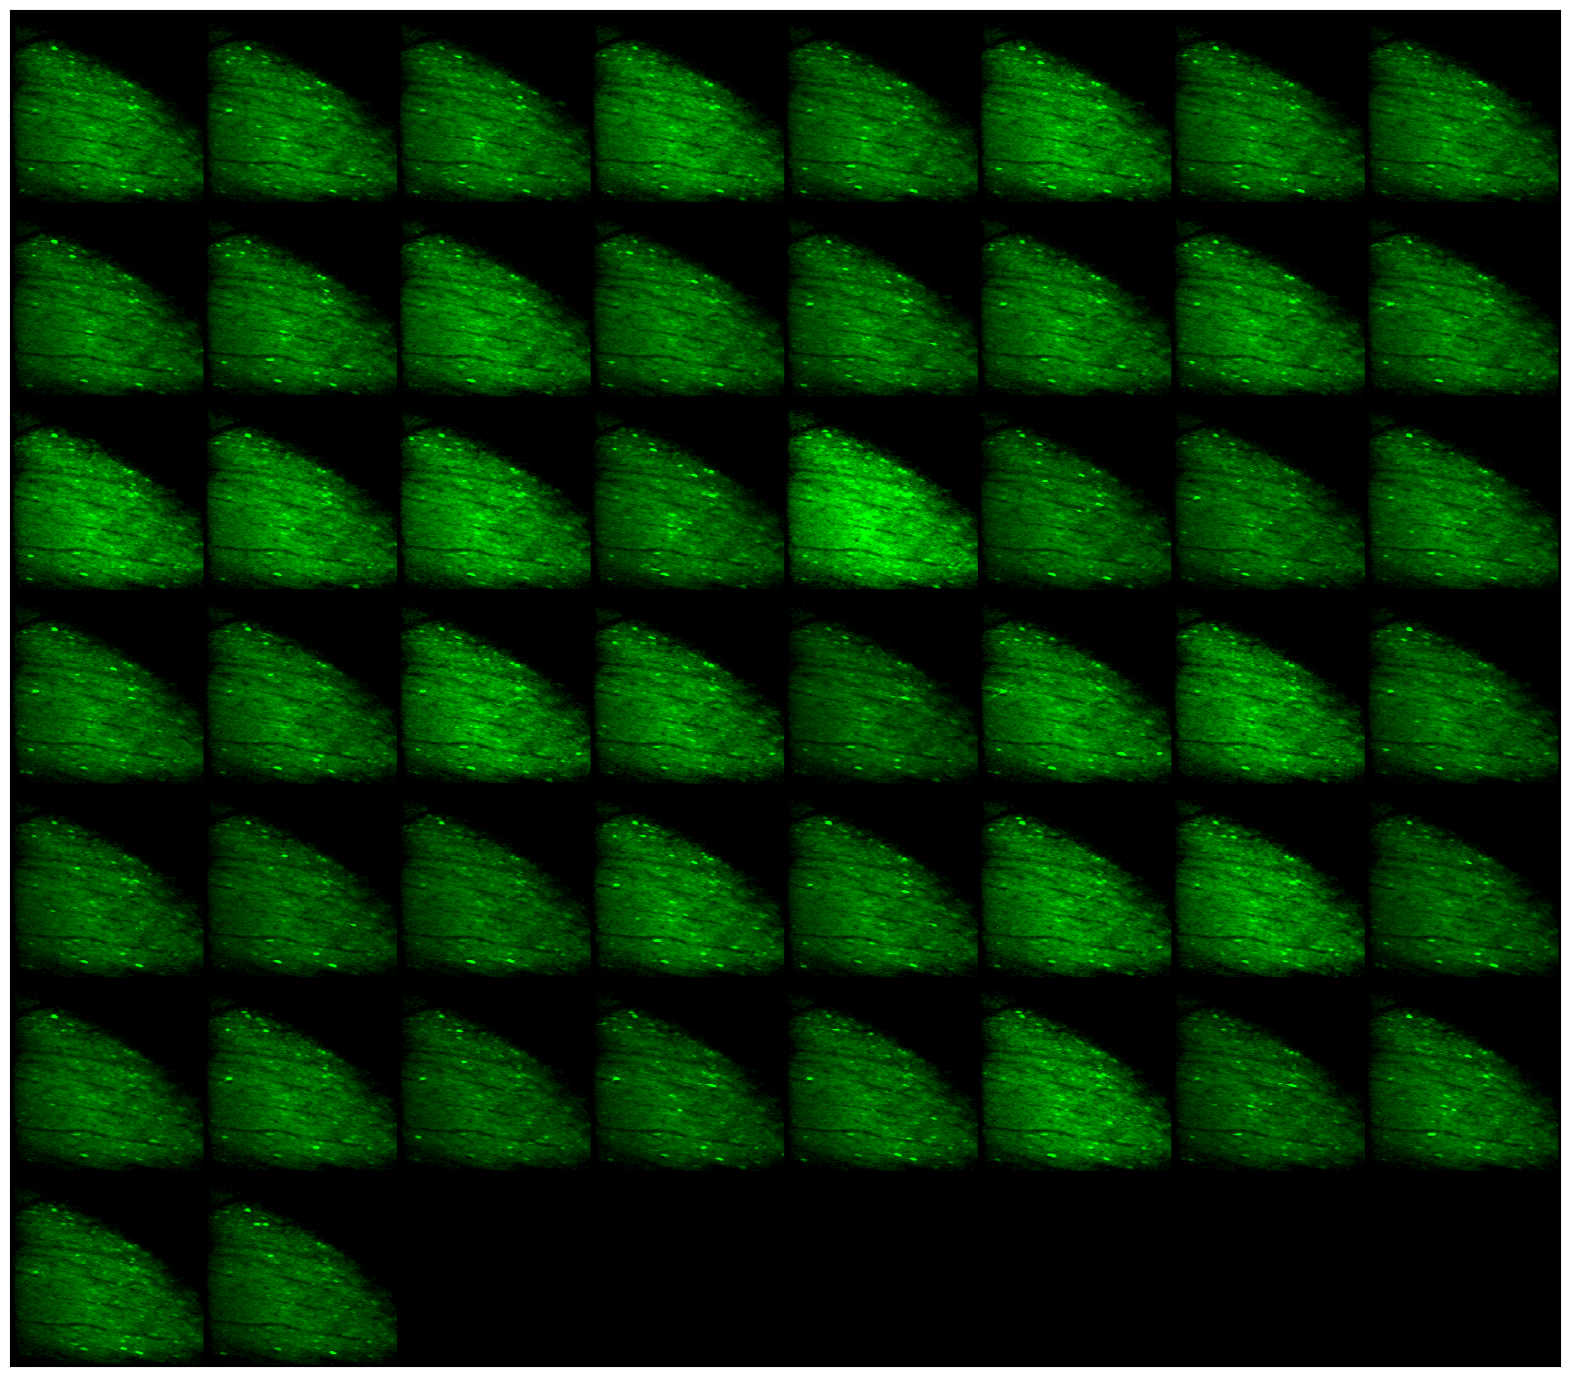

In [17]:
show_images(real_images)